In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

#pd.set_option('display.max_rows', 1000); pd.set_option('display.max_columns', 1000); pd.set_option('display.width', 1000)


# Load data

In [74]:
df = pd.read_csv("/Users/AdenHsu/Documents/DataFolder/MACSS-FULLDemogData_2026-01-14_deidentified_SB(in).csv")

# Description

In [75]:
df.head()

,record_id,age_years,age_months,dx,sex,gender,gender: Other (Please Specify),Religion,Ethnicity,What is your annual household income?,Black or African American,Asian,White,Native Hawaiian or Other Pacific Islander,Native America/Alaska Native,Other,Other (please specify):,Current medications:,ASD (formal diagnosis) (choice=Participant),ASD traits (choice=Participant),Developmental Delay (choice=Participant),Intellectual Disability (choice=Participant),ADHD (choice=Participant),Learning Disability (choice=Participant),Depression (choice=Participant),Anxiety (choice=Participant),OCD/Tics/Tourette's (choice=Participant),Bipolar Disorder (choice=Participant),Schizophrenia/psychosis (choice=Participant),Eating Disorder (choice=Participant),Seizures (choice=Participant),Genetic Syndromes (choice=Participant),Other: (choice=Participant),Other (please specify):.1,adost_exam_date,ados_examiner,ados_exact_age,ados_exact_age_months,ados_modules_complete,ados_comparison_score,ados4naclass,ados4narrb,ados4natot,ados4nas_sa_tot,ados4nas,ados4nal,body_perception_questionnaire_complete,bpq_diarrhea,bpq_dig_probs,bpq_indigestion,bpq_constipate,bpq_swallow_freq,bpq_cough,bpq_dry_mouth,bpq_breath_fast,bpq_eye_tears,bpq_dig_noise,bpq_body_swell,bpq_defecate,bpq_mus_ten,bpq_bloating,bpq_face_mus_ten,bpq_goosebumps,bpq_stomach_pain,bpq_stomach,bpq_palm_sweat,bpq_forehead_sweat,bpq_lip_tremor,bpq_armpit_sweat,bpq_face_temp,bpq_teeth_grind,bpq_jitter,bpq_hair_spiking,bpq_diff_focus,bpq_swallow_urge,bpq_heart_beat,bpq_constipated,bpq_dif_breathing,bpq_dif_talking,bpq_irr_hb,bpq_stick_food,bpq_short_breath,bpq_diff_coord,bpq_diff_eating,bpq_cough_eating,bpq_sal_gag,bpq_chest_pain,bpq_eat_gag,bpq_cough_talk,bpq_low_o2,bpq_eye_control,bpq_vomit,bpq_sout_stomach,srs_date,srs_sex,srs_sex_other,srs_age_months,srs_asr_score,srs_asr_tscore_auto,srs_asr_awr,srs_asr_awr_t,srs_asr_scogs,srs_asr_scogs_t,srs_asr_scoms,srs_asr_scoms_t,srs_asr_smots,srs_asr_smots_t,srs_asr_rirbs,srs_asr_rirbs_t,srs_2_adult_self_report_calc_complete,wasi_date,wasi_age_months,wasi_vci_composite,wasi_pri_composite,wasi_fsiq4_composite,wasi_fsiq2_composite,wasi_full2_tscore,wasi_full4_tscore,wasi_pr_tscore,wasi_vc_tscore,ans_connect_postq
0,SB0001,34.0,411.0,ASD,M,Male,NaN,NaN,Hispanic/Latino,"$35,000 - $49,999",1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,8/12/2021,18.0,29.818545,357.785808,2.0,7.0,1.0,5.0,12.0,7.0,5.0,2.0,2.0,3.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,10/17/2024,1.0,NaN,395.959264,88.0,67.0,9.0,58.0,19.0,70.0,28.0,65.0,15.0,62.0,17.0,68.0,2.0,8/12/2021,357.785808,99.0,120.0,110.0,103.0,55.0,60.0,44.0,64.0,10.0
1,SB0002,25.0,307.0,TD,M,Male,NaN,NaN,Not Hispanic/Latino,"$100,000 - $149,999",0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,10/17/2024,1.0,NaN,291.819974,36.0,48.0,5.0,47.0,5.0,46.0,9.0,46.0,12.0,57.0,5.0,48.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
2,SB0003,24.0,288.0,ASD,F,Female,NaN,Jewish,Not Hispanic/Latino,"$200,000 and over",0.0,1.0,0.0,0.0,0.0,1.0,Jewish,acetazolamide aripiprazole metoprolol succinate,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2/15/2023,18.0,21.103787,253.219448,2.0,9.0,1.0,3.0,17.0,14.0,13.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,3.0,3.0,1.0,4.0,1.0,4.0,3.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2,1.0,2.0,2.0,1.0,11/1/2024,2.0,NaN,273.751643,130.0,82.0,15.0,75.0,19.0,70.0,43.0,79.0,30.0,87.0,26.0,83.0,2.0,3/13/2023,254.073587,126.0,113.0,123.0,135.0,54.0,61.0,80.0,55.0,7.0
3,

In [76]:
df.tail()

,record_id,age_years,age_months,dx,sex,gender,gender: Other (Please Specify),Religion,Ethnicity,What is your annual household income?,Black or African American,Asian,White,Native Hawaiian or Other Pacific Islander,Native America/Alaska Native,Other,Other (please specify):,Current medications:,ASD (formal diagnosis) (choice=Participant),ASD traits (choice=Participant),Developmental Delay (choice=Participant),Intellectual Disability (choice=Participant),ADHD (choice=Participant),Learning Disability (choice=Participant),Depression (choice=Participant),Anxiety (choice=Participant),OCD/Tics/Tourette's (choice=Participant),Bipolar Disorder (choice=Participant),Schizophrenia/psychosis (choice=Participant),Eating Disorder (choice=Participant),Seizures (choice=Participant),Genetic Syndromes (choice=Participant),Other: (choice=Participant),Other (please specify):.1,adost_exam_date,ados_examiner,ados_exact_age,ados_exact_age_months,ados_modules_complete,ados_comparison_score,ados4naclass,ados4narrb,ados4natot,ados4nas_sa_tot,ados4nas,ados4nal,body_perception_questionnaire_complete,bpq_diarrhea,bpq_dig_probs,bpq_indigestion,bpq_constipate,bpq_swallow_freq,bpq_cough,bpq_dry_mouth,bpq_breath_fast,bpq_eye_tears,bpq_dig_noise,bpq_body_swell,bpq_defecate,bpq_mus_ten,bpq_bloating,bpq_face_mus_ten,bpq_goosebumps,bpq_stomach_pain,bpq_stomach,bpq_palm_sweat,bpq_forehead_sweat,bpq_lip_tremor,bpq_armpit_sweat,bpq_face_temp,bpq_teeth_grind,bpq_jitter,bpq_hair_spiking,bpq_diff_focus,bpq_swallow_urge,bpq_heart_beat,bpq_constipated,bpq_dif_breathing,bpq_dif_talking,bpq_irr_hb,bpq_stick_food,bpq_short_breath,bpq_diff_coord,bpq_diff_eating,bpq_cough_eating,bpq_sal_gag,bpq_chest_pain,bpq_eat_gag,bpq_cough_talk,bpq_low_o2,bpq_eye_control,bpq_vomit,bpq_sout_stomach,srs_date,srs_sex,srs_sex_other,srs_age_months,srs_asr_score,srs_asr_tscore_auto,srs_asr_awr,srs_asr_awr_t,srs_asr_scogs,srs_asr_scogs_t,srs_asr_scoms,srs_asr_scoms_t,srs_asr_smots,srs_asr_smots_t,srs_asr_rirbs,srs_asr_rirbs_t,srs_2_adult_self_report_calc_complete,wasi_date,wasi_age_months,wasi_vci_composite,wasi_pri_composite,wasi_fsiq4_composite,wasi_fsiq2_composite,wasi_full2_tscore,wasi_full4_tscore,wasi_pr_tscore,wasi_vc_tscore,ans_connect_postq
57,SB0071,28.0,336.0,TD,F,Female,NaN,Agnostic Atheist,Not Hispanic/Latino,"$200,000 and over",0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,5/8/2025,2.0,NaN,327.956636,22.0,44.0,2.0,38.0,9.0,53.0,4.0,41.0,6.0,47.0,1.0,42.0,2.0,8/8/2024,318.988174,NaN,NaN,NaN,131.0,NaN,57.0,79.0,NaN,5.0
58,SB0073,32.0,384.0,TD,F,Female,NaN,NaN,Not Hispanic/Latino,"$200,000 and over",1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,6/12/2025,2.0,NaN,377.036794,26.0,45.0,6.0,49.0,3.0,42.0,7.0,44.0,7.0,49.0,3.0,45.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
59,SB0087,33.0,396.0,TD,F,Female,NaN,Catholic,Hispanic/Latino,"$25,000 - $34,999",0.0,0.0,0.0,0.0,0.0,1.0,Hispanic,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,2.0,8/25/2025,2.0,NaN,391.228647,10.0,39.0,5.0,47.0,2.0,41.0,1.0,38.0,2.0,41.0,0.0,40.0,2.0,10/23/2025,393.166886,102.0,73.0,86.0,83.0,52.0,29.0,51.0,38.0,9.0
60,SB0089,22.0,267.0,TD,F,Female,NaN,NaN,Not Hispanic/Latino,"$200,000 and over",0.0,0.0,0.0,0.

In [77]:
df.shape

(62, 121)

In [78]:
df.describe

<bound method NDFrame.describe of    record_id  age_years  age_months   dx  sex                     gender gender: Other (Please Specify)          Religion            Ethnicity What is your annual household income?   Black or African American  Asian  White  Native Hawaiian or Other Pacific Islander  Native America/Alaska Native  Other Other (please specify):                               Current medications:  ASD (formal diagnosis) (choice=Participant)  ASD traits (choice=Participant)  Developmental Delay (choice=Participant)  Intellectual Disability (choice=Participant)  ADHD (choice=Participant)  Learning Disability (choice=Participant)  Depression (choice=Participant)  Anxiety (choice=Participant)  OCD/Tics/Tourette's (choice=Participant)  Bipolar Disorder (choice=Participant)  Schizophrenia/psychosis (choice=Participant)  Eating Disorder (choice=Participant)  Seizures (choice=Participant)  Genetic Syndromes (choice=Participant)  Other: (choice=Participant)                          

In [79]:
df.info

<bound method DataFrame.info of    record_id  age_years  age_months   dx  sex                     gender gender: Other (Please Specify)          Religion            Ethnicity What is your annual household income?   Black or African American  Asian  White  Native Hawaiian or Other Pacific Islander  Native America/Alaska Native  Other Other (please specify):                               Current medications:  ASD (formal diagnosis) (choice=Participant)  ASD traits (choice=Participant)  Developmental Delay (choice=Participant)  Intellectual Disability (choice=Participant)  ADHD (choice=Participant)  Learning Disability (choice=Participant)  Depression (choice=Participant)  Anxiety (choice=Participant)  OCD/Tics/Tourette's (choice=Participant)  Bipolar Disorder (choice=Participant)  Schizophrenia/psychosis (choice=Participant)  Eating Disorder (choice=Participant)  Seizures (choice=Participant)  Genetic Syndromes (choice=Participant)  Other: (choice=Participant)                          Ot

# Data Preparation

In [80]:
# strip unnecessary spaces off the columns
df.columns = df.columns.str.strip()

# rename the columns
df = df.rename(columns = {
    "record_id":"id",
    "Religion":"religion",
    "Ethnicity":"hispanic", 
    "What is your annual household income?":"income",
    'Black or African American':'black',
    'Asian':'asian',
    'White':'white',
    'Native Hawaiian or Other Pacific Islander':'pacific islander',
    'Native America/Alaska Native':'native american',
    'Other':'other',
    'Current medications:':'medication',
    'ASD (formal diagnosis) (choice=Participant)':"asd",
    'ASD traits (choice=Participant)':'asd_traits',
    'Developmental Delay (choice=Participant)':"developmental_delay",
    'Intellectual Disability (choice=Participant)':'intellectual_disability',
    'ADHD (choice=Participant)':'adhd',
    'Learning Disability (choice=Participant)':'learning_disability',
    'Depression (choice=Participant)':'depression',
    'Anxiety (choice=Participant)':'anxiety',
    "OCD/Tics/Tourette's (choice=Participant)":'ocd_tics_tourettes',
    'Bipolar Disorder (choice=Participant)':'bipolar',
    'Schizophrenia/psychosis (choice=Participant)' : 'schizophrenia',
    'Eating Disorder (choice=Participant)':'eating_disorder',
    'Seizures (choice=Participant)':'seizures',
    'Genetic Syndromes (choice=Participant)':'genetic_syndromes',
    'Other: (choice=Participant)':'other_condition',
    'other':'other_race',
    })

# create new age column to replace age_months and age_year
if 'age_months' in df.columns:
    df['age'] = df['age_months'] / 12
    df['age'] = df['age'].round(2)

# drop unnecessary columns
if 'age_years' in df.columns:
    df = df.drop(['age_years',
        'age_months',
        'gender: Other (Please Specify)',
        'Other (please specify):',
        'Other (please specify):.1',
        'srs_sex',
        'srs_sex_other',
        'srs_date',
        'adost_exam_date',
        'ados_examiner',
        'ados_exact_age',
        'ados_exact_age_months',
        'body_perception_questionnaire_complete',
        'srs_age_months',
        'wasi_date',
        'wasi_age_months',
        ],axis=1,errors='ignore')
df.insert(1, "age", df.pop("age"))
df['gender'] = df['gender'].replace({'Transgender Man':'Male',
                                     'Gender Variant/Non-Binary':'Other'})
df['hispanic'] = df['hispanic'].replace({'Not Hispanic/Latino':0,
                                         'Hispanic/Latino':1})
df['dx'] = df['dx'].replace({'TD':0,'ASD':1})

# change income to a numerical variable
df['income'] = df['income'].replace({
    "$0 - $15,000":7500,
    '$15,000 - $24,999':20000,
    '$25,000 - $34,999':30000,
    "$35,000 - $49,999":42500,
    "$50,000 - $74,999":62500,
    '$75,000 - $99,999':82500,
    "$100,000 - $149,999":125000,
    "$150,000 - $199,999":175000,
    "$200,000 and over":200000}).astype(float)

# drop medication column
if 'medication' in df.columns:
    df = df.drop('medication',axis=1)
# change religion column to religion y/n
df['religion'] = df['religion'].fillna(0)
df['religion'] = df['religion'].replace({"none":0,
                                         "NA ":0,
})
df['religion'] = (df['religion'] != 0).astype(int)

# there's one row at the end that is just n/a for everything - drop that
df = df.drop(index=61)

In [81]:
display(df.isnull().sum())
# majority of the null rows come from wasi and ados. ados is essentiall used to diagnose autism, so don't use that for prediction. wasi will be imputed with knn?

id                                        0
age                                       0
dx                                        0
sex                                       0
gender                                    0
religion                                  0
hispanic                                  0
income                                    1
black                                     0
asian                                     0
white                                     0
pacific islander                          0
native american                           0
other                                     0
asd                                       0
asd_traits                                0
developmental_delay                       0
intellectual_disability                   0
adhd                                      0
learning_disability                       0
depression                                0
anxiety                                   0
ocd_tics_tourettes              

In [82]:
#df['dx'].value_counts()
print(f"There are {df['dx'].value_counts()[0]} instances of TD and {df['dx'].value_counts()[1]} instances of ASD")
print(f"TD makes up {df['dx'].value_counts()[0]/(19+42) * 100}% of the dataset and ASD makes up {df['dx'].value_counts()[1]/(19+42) * 100}%")

There are 42 instances of TD and 19 instances of ASD
TD makes up 68.85245901639344% of the dataset and ASD makes up 31.147540983606557%


In [83]:
demographic_columns = (['age','sex','religion','hispanic','income','black','asian','white','pacific islander','native american','other'])
clinical_columns = (['developmental_delay',
                     'intellectual_disability',
                     'adhd','learning_disability',
                     'depression','anxiety',
                     'ocd_tics_tourettes',
                     'bipolar','schizophrenia',
                     'eating_disorder',
                     'seizures',
                     'genetic_syndromes',
                     'other_condition'])
ados_columns = ([])
bpq_columns = ([])
srs_columns = []
wasi_columns = []

# organize each column into sections
for i in df.columns:
    if i[0:3] == 'ado':
        ados_columns.append(i)
    elif i[0:3] == 'bpq':
        bpq_columns.append(i)
    elif i[0:3] == 'srs':
        srs_columns.append(i)
    elif i[0:3] == 'was':
        wasi_columns.append(i)
training_columns = (demographic_columns + clinical_columns+bpq_columns+wasi_columns+['ans_connect_postq'])

In [84]:
y = df['dx']
X = df[training_columns]

# Split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

In [86]:
# convert object to pandas category
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')

for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].astype('category')

# use knn imputer after split to avoid leakage
imputer = KNNImputer(n_neighbors=3)

# use knn imputer to impute one missing income variable
X_train[['income']] = imputer.fit_transform(X_train[['income']])
X_test[['income']]  = imputer.transform(X_test[['income']])

# replace all missing wasi with knn
X_train[wasi_columns] = imputer.fit_transform(X_train[wasi_columns])
X_test[wasi_columns]  = imputer.transform(X_test[wasi_columns])

# one-hot
cat_cols = X_train.select_dtypes(include=['category','object']).columns

X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# align
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# scale for use in logreg and other distance based models
scaler = StandardScaler()
X_train_enc_scaled = scaler.fit_transform(X_train_enc)
X_test_enc_scaled = scaler.transform(X_test_enc)

In [87]:
# XGB classifier
model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    enable_categorical=True
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [88]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.89      0.84         9
         1.0       0.67      0.50      0.57         4

    accuracy                           0.77        13
   macro avg       0.73      0.69      0.71        13
weighted avg       0.76      0.77      0.76        13



In [89]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_enc, y_train)
y_pred = rf_model.predict(X_test_enc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

         0.0       0.80      0.89      0.84         9
         1.0       0.67      0.50      0.57         4

    accuracy                           0.77        13
   macro avg       0.73      0.69      0.71        13
weighted avg       0.76      0.77      0.76        13



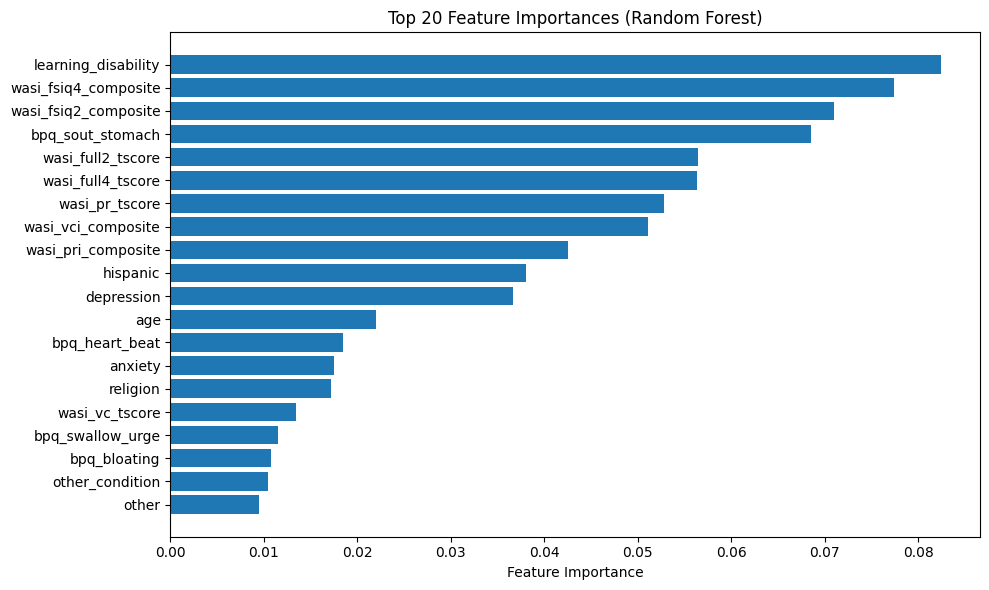

In [90]:
# feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)  # show top 20

# plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1])  # reversed for descending order
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [91]:
# define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

roc_data = {}
lift_data = {}
percentile_grid = np.linspace(0, 1, len(y_test))


# establish parameter grids
param_grids = {
    "Logistic Regression": {
        'clf__C': [0.01, 0.1, 1, 10]
    },
    "Random Forest": {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [None, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]
    },
    "XGBoost": {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.1, 0.2]
    },
    "SVM": {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf']
    },
    "KNN": {
        'clf__n_neighbors': [3, 5, 7],
        'clf__weights': ['uniform', 'distance']
    }
}

pipelines = {}
for name, model in models.items():
    if name in ["Logistic Regression", "SVM", "KNN"]:
        pipelines[name] = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
    else:
        pipelines[name] = Pipeline([
            ('clf', model)
        ])
# 5 fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    print(f"\n=== {name} ===")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring='balanced_accuracy',
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train_enc, y_train)  # always use X_train_enc here

    # best model
    best_model = grid.best_estimator_

    # predict on test set
    y_pred = best_model.predict(X_test_enc)
    y_proba = best_model.predict_proba(X_test_enc)[:, 1]

    print("Best parameters:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

    # ----- Lift curve -----
    sorted_indices = np.argsort(y_proba)[::-1]
    y_true_sorted = y_test.values[sorted_indices]

    cumulative_true = np.cumsum(y_true_sorted)
    total_positives = np.sum(y_true_sorted)

    positive_rate = total_positives / len(y_true_sorted)
    lift = cumulative_true / (np.arange(1, len(y_true_sorted)+1) * positive_rate)

    lift_interp = np.interp(
        percentile_grid,
        np.arange(1, len(lift)+1)/len(lift),
        lift
    )

    lift_data[name] = lift_interp


=== Logistic Regression ===
Best parameters: {'clf__C': 10}
Accuracy: 0.6923076923076923
Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      0.89      0.80         9
         1.0       0.50      0.25      0.33         4

    accuracy                           0.69        13
   macro avg       0.61      0.57      0.57        13
weighted avg       0.66      0.69      0.66        13

ROC AUC Score: 0.8611111111111112

=== Random Forest ===
Best parameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}
Accuracy: 0.8461538461538461
Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      1.00      0.90         9
         1.0       1.00      0.50      0.67         4

    accuracy                           0.85        13
   macro avg       0.91      0.75      0.78        13
weighted avg       0.87      0.85      0.83        13

ROC AUC Score: 0.930555555

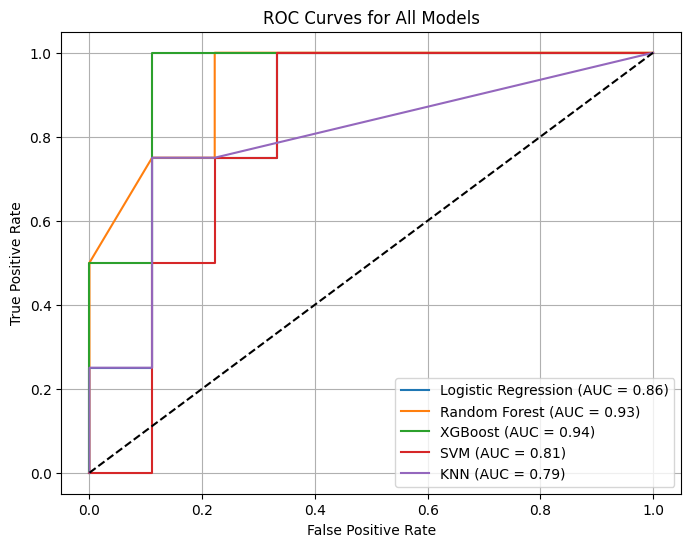

In [92]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True)
plt.show()


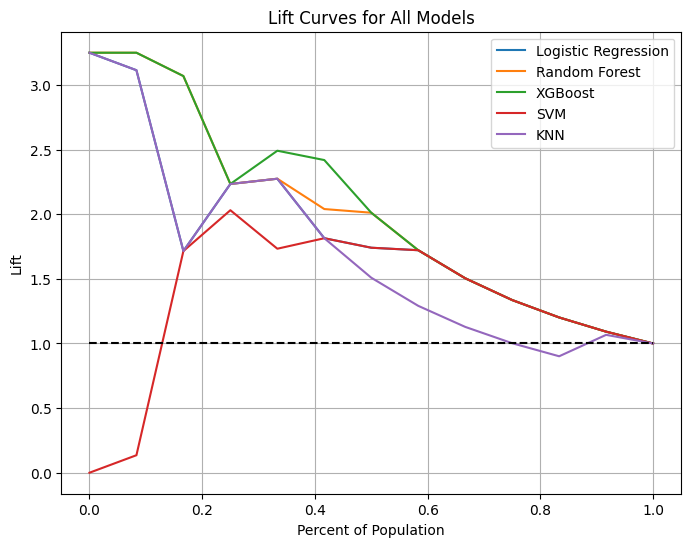

In [93]:
plt.figure(figsize=(8,6))

for name, lift_curve in lift_data.items():
    plt.plot(percentile_grid, lift_curve, label=name)

plt.plot([0,1], [1,1], 'k--')
plt.xlabel("Percent of Population")
plt.ylabel("Lift")
plt.title("Lift Curves for All Models")
plt.legend()
plt.grid(True)
plt.show()